In [1]:
#写一个大循环，循环不同的分辨率
# 匹配数目与平均降水
from scipy import stats
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib as mpl
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeat
import matplotlib.pyplot as plt
from cartopy.io.shapereader import Reader
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.feature import ShapelyFeature
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import BoundaryNorm
a=0.2
p = int(7 / a)
q = int(11 / a)

c:\ProgramData\miniconda3\envs\pystudy\Lib\site-packages\pyproj\__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [2]:
gauge_pre_grided=np.load('gauge_pre_grided.npy')
sate_pre=np.load("precip_all_hour_satellite.npy")

In [3]:
np.nanmean(gauge_pre_grided)

np.float64(0.1117212569321073)

In [17]:
np.nanmean(sate_pre)

np.float64(0.14930022573529828)

In [18]:
gauge_pre_grided.shape

(43848, 35, 55)

In [3]:
huatus = np.zeros((8,) + gauge_pre_grided.shape[1:])  # 前4个是地面数据，后4个是卫星数据

sate_pre[(gauge_pre_grided<0.1) & (sate_pre<0.1)]=np.nan
gauge_pre_grided[(gauge_pre_grided<0.1) & (sate_pre<0.1)]=np.nan
pre_minus = sate_pre - gauge_pre_grided


# 定义每年的小时数（已知两个闰年）
hours_per_year = [8784, 8760, 8760, 8760, 8784]

# 预计算各季节起始索引（基于每年1月1日0时为起点）
season_slices = [
    # 春季：3-5月（按闰年计算，实际使用时根据年份索引选择）
    {"start": 31*24 + 28*24, "end": 31*24 + 28*24 + 92*24},  # 3/1 0:00 ~ 5/31 23:00
    
    # 夏季：6-8月
    {"start": 31*24 + 28*24 + 92*24, "end": 31*24 + 28*24 + 92*24 + 92*24},
    
    # 秋季：9-11月
    {"start": 31*24 + 28*24 + 184*24, "end": 31*24 + 28*24 + 184*24 + 91*24},
    
    # 冬季：当年12月 + 次年1-2月（修正为仅当前年）
    {"start": 334*24, "end": 365*24},  # 12/1 0:00 ~ 12/31 23:00
    {"pre_start": 0, "pre_end": 59*24}  # 1/1 0:00 ~ 2/28 23:00
]

# 动态生成各年实际索引（考虑闰年）
def get_season_indices(year_idx, is_leap):
    base = sum(hours_per_year[:year_idx])
    leap_offset = 24 if is_leap else 0
    
    return {
        "spring": (
            base + (31*24 + 28*24 + leap_offset),  # 3/1 0:00
            base + (31*24 + 28*24 + 92*24 + leap_offset)
        ),
        "summer": (
            base + (31*24 + 28*24 + 92*24 + leap_offset),
            base + (31*24 + 28*24 + 184*24 + leap_offset)
        ),
        "autumn": (
            base + (31*24 + 28*24 + 184*24 + leap_offset),
            base + (31*24 + 28*24 + 275*24 + leap_offset)
        ),
        "winter": [
            (base + 334*24, base + (366 if is_leap else 365)*24),  # 12/1 ~ 年底
            (base, base + 59*24 + (24 if is_leap else 0))          # 1/1 ~ 2/29/28
        ]
    }


# 初始化季节数据容器
minus_seasons = [[] for _ in range(4)]
# sate_seasons = [[] for _ in range(4)]

# 处理每个年份的数据
cursor = 0
for year in range(5):
    is_leap = (hours_per_year[year] == 8784)
    indices = get_season_indices(year, is_leap)
    
    # 切割四季数据
    for i, season in enumerate(["spring", "summer", "autumn"]):
        start, end = indices[season]
        minus_seasons[i].append(pre_minus[start:end])
        # sate_seasons[i].append(sate_pre[start:end])
    
    # 冬季特殊处理：12月 + 1-2月（同一年内）
    winter12 = pre_minus[indices["winter"][0][0]:indices["winter"][0][1]]
    winter1_2 = pre_minus[indices["winter"][1][0]:indices["winter"][1][1]]
    minus_seasons[3].append(np.concatenate([winter1_2, winter12]))
    
    # sate_winter12 = sate_pre[indices["winter"][0][0]:indices["winter"][0][1]]
    # sate_winter1_2 = sate_pre[indices["winter"][1][0]:indices["winter"][1][1]]
    # sate_seasons[3].append(np.concatenate([sate_winter1_2, sate_winter12]))

# 计算平均值
for i in range(4):
    huatus[i] = np.sqrt(np.nanmean(np.concatenate(minus_seasons[i], axis=0)**2, axis=0))
    huatus[i+4] = np.nanmean(np.concatenate(minus_seasons[i], axis=0), axis=0)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_22200\496394368.py:79: RuntimeWarning: Mean of empty slice
  huatus[i] = np.sqrt(np.nanmean(np.concatenate(minus_seasons[i], axis=0)**2, axis=0))
C:\Users\Administrator\AppData\Local\Temp\ipykernel_22200\496394368.py:80: RuntimeWarning: Mean of empty slice
  huatus[i+4] = np.nanmean(np.concatenate(minus_seasons[i], axis=0), axis=0)


In [20]:
# #小于0.1时表示没有误差
# sate_pre[(gauge_pre_grided<0.1) & (sate_pre<0.1)]=np.nan
# gauge_pre_grided[(gauge_pre_grided<0.1) & (sate_pre<0.1)]=np.nan


# pre_minus = sate_pre - gauge_pre_grided

# huatus={}
# huatus[0]=np.sqrt(np.nanmean(((np.append(pre_minus[0:744],pre_minus[7320:8784],axis=0)) ** 2),axis=0))
# huatus[1]=np.sqrt(np.nanmean(((pre_minus[744:2952]) ** 2),axis=0))
# huatus[2]=np.sqrt(np.nanmean(((pre_minus[2952:5136]) ** 2),axis=0))
# huatus[3]=np.sqrt(np.nanmean(((pre_minus[5136:7320]) ** 2),axis=0))

# huatus[4]=np.nanmean((np.append(pre_minus[0:744],pre_minus[7320:8784],axis=0)),axis=0)
# huatus[5]=np.nanmean((pre_minus[744:2952]),axis=0)
# huatus[6]=np.nanmean((pre_minus[2952:5136]),axis=0)
# huatus[7]=np.nanmean((pre_minus[5136:7320]),axis=0)

In [21]:
print(np.nanmean(huatus[0]),np.nanmean(huatus[1]),np.nanmean(huatus[2]),np.nanmean(huatus[3]))
print(np.nanmean(huatus[4]),np.nanmean(huatus[5]),np.nanmean(huatus[6]),np.nanmean(huatus[7]))
print(np.array([np.nanmean(huatus[4]),np.nanmean(huatus[5]),np.nanmean(huatus[6]),np.nanmean(huatus[7])]).mean())


1.6452600361228382 3.3472762511551832 1.8419051347087285 1.2573544759141313
0.24735438401197413 0.35331888197030387 0.19784146715215448 0.3839116971098386
0.29560660756106777


In [4]:
plt.rcParams["font.sans-serif"] = ["Arial"]  # 用于显示中文,Arial
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False  # 用于显示中文


# --设置shp路径，数据集已公开
shp_path = r"E:\0000000000\map_data\bou2_4p.dbf"
# --设置tif路径，数据集已公开
tif_path = r"E:\0000000000\map_data\地形数据\NE1_50M_SR_W.tif"

bins = np.arange(0,5.52,0.02)#,np.arange(2,2.5,0.01))
#bins = np.arange(0,0.2,0.01)
nbin = len(bins) + 1
cmap1 =plt.get_cmap("Spectral_r", nbin)
norm1 = mpl.colors.BoundaryNorm(bins, nbin,extend='both')

bins = np.arange(-1.,1.01,0.01)
#bins = np.arange(0,0.2,0.01)
nbin = len(bins) + 1
cmap2 = plt.get_cmap("coolwarm", nbin)
norm2 = mpl.colors.BoundaryNorm(bins, nbin,extend='both')


# import matplotlib as mpl
# import matplotlib.colors as colors
# colorslist = ['white','skyblue','Cyan','red']
# # colorslist = ['white','green','blue','red']
# #将四种色插值为具有300个渐变色的色板
# bins =  np.arange(0,2.52,0.02)
# nbin = len(bins) + 2
# cmap1 = colors.LinearSegmentedColormap.from_list('123',colorslist,nbin)
# norm1 = mpl.colors.BoundaryNorm(bins, nbin, extend='both')

In [23]:
print(np.nanstd(huatus[0])/np.nanmean(huatus[0]),np.nanstd(huatus[1])/np.nanmean(huatus[1]),np.nanstd(huatus[2])/np.nanmean(huatus[2]),np.nanstd(huatus[3])/np.nanmean(huatus[3]))
print(np.nanstd(huatus[4])/np.nanmean(huatus[4]),np.nanstd(huatus[5])/np.nanmean(huatus[5]),np.nanstd(huatus[6])/np.nanmean(huatus[6]),np.nanstd(huatus[7])/np.nanmean(huatus[7]))

0.21494805007431042 0.17307558188219066 0.2855632074377529 0.6635839365592164
0.4325317402533991 0.5054652970717959 0.735776355284936 0.9339930089949692


In [5]:
num=np.load("num_station_gauge.npy")
huatus[1]
num_flat = num.flatten()
huatus_1_flat = huatus[1].flatten()
valid_mask = ~np.isnan(num_flat) & ~np.isnan(huatus_1_flat)
num_valid = num_flat[valid_mask]
huatus_1_valid = huatus_1_flat[valid_mask]

# 使用scipy.stats.pearsonr计算相关系数和p值
correlation_coef, p_value = stats.pearsonr(num_valid, huatus_1_valid)
sample_size = len(num_valid)  # 样本数

# 输出结果
print(f"相关系数 (r): {correlation_coef:.4f}")
print(f"p值: {p_value:.4e}")
print(f"样本数 (n): {sample_size}")

# 如果需要，也可以保留原来的相关系数矩阵形式
correlation_matrix = np.corrcoef(num_valid, huatus_1_valid)
print(f"\n相关系数矩阵:\n{correlation_matrix}")

相关系数 (r): -0.3305
p值: 3.8768e-44
样本数 (n): 1681

相关系数矩阵:
[[ 1.         -0.33052843]
 [-0.33052843  1.        ]]


In [ ]:
rho, p = stats.spearmanr(num_valid, huatus_1_valid)
print(f"Spearman相关系数: {rho:.4f}")


Spearman相关系数: -0.3318


In [21]:
# Calculate Bivariate Moran's I (BMI) for spatial correlation between num and huatus[1]
# BMI measures the spatial correlation between two variables

def build_spatial_weights_queen(nrows, ncols):
    """
    Build Queen contiguity spatial weights matrix (8 neighbors)
    Returns a sparse-like representation: list of (i, j, weight) tuples
    """
    weights = []
    n = nrows * ncols
    
    for i in range(nrows):
        for j in range(ncols):
            idx = i * ncols + j
            # Check 8 neighbors (Queen contiguity)
            for di in [-1, 0, 1]:
                for dj in [-1, 0, 1]:
                    if di == 0 and dj == 0:
                        continue
                    ni, nj = i + di, j + dj
                    if 0 <= ni < nrows and 0 <= nj < ncols:
                        nidx = ni * ncols + nj
                        weights.append((idx, nidx, 1.0))
    
    return weights

def bivariate_morans_i(x, y, weights, nrows, ncols):
    """
    Calculate Bivariate Moran's I
    I_xy = (n/W) * sum_i sum_j w_ij * (x_i - x_mean) * (y_j - y_mean) / 
           (sqrt(sum_i (x_i - x_mean)^2) * sqrt(sum_j (y_j - y_mean)^2))
    
    Parameters:
    x, y: 2D arrays (nrows, ncols)
    weights: list of (i, j, weight) tuples
    """
    # Flatten arrays
    x_flat = x.flatten()
    y_flat = y.flatten()
    
    # Remove NaN values and create mask
    valid_mask = ~(np.isnan(x_flat) | np.isnan(y_flat))
    n_valid = np.sum(valid_mask)
    
    if n_valid < 2:
        return np.nan, np.nan
    
    # Get valid indices
    valid_indices = np.where(valid_mask)[0]
    
    # Calculate means
    x_mean = np.nanmean(x_flat[valid_mask])
    y_mean = np.nanmean(y_flat[valid_mask])
    
    # Center the data
    x_centered = x_flat - x_mean
    y_centered = y_flat - y_mean
    
    # Calculate numerator: sum of w_ij * (x_i - x_mean) * (y_j - y_mean)
    numerator = 0.0
    W = 0.0  # Sum of all weights
    
    # Only consider valid pairs
    for i, j, w in weights:
        if i in valid_indices and j in valid_indices:
            numerator += w * x_centered[i] * y_centered[j]
            W += w
    
    if W == 0:
        return np.nan, np.nan
    
    # Calculate denominator
    x_var = np.nansum(x_centered[valid_mask]**2)
    y_var = np.nansum(y_centered[valid_mask]**2)
    
    if x_var == 0 or y_var == 0:
        return np.nan, np.nan
    
    denominator = np.sqrt(x_var * y_var)
    
    # Calculate Bivariate Moran's I
    I_xy = (n_valid / W) * (numerator / denominator)
    
    # Calculate expected value and variance for significance test
    # Under null hypothesis, E[I] = -1/(n-1)
    E_I = -1.0 / (n_valid - 1) if n_valid > 1 else 0
    
    # Simplified variance calculation (for large n)
    # Var[I] ≈ (n^2 * S1 - n * S2 + 3 * W^2) / (W^2 * (n^2 - 1))
    # Pre-compute neighbor counts for efficiency
    valid_set = set(valid_indices)
    neighbor_counts = {}
    for i, j, w in weights:
        if i in valid_set and j in valid_set:
            if i not in neighbor_counts:
                neighbor_counts[i] = 0
            if j not in neighbor_counts:
                neighbor_counts[j] = 0
            neighbor_counts[i] += 1
            neighbor_counts[j] += 1
    
    S1 = 0.0
    S2 = 0.0
    for i, j, w in weights:
        if i in valid_set and j in valid_set:
            count_i = neighbor_counts.get(i, 0)
            count_j = neighbor_counts.get(j, 0)
            S1 += w * (count_i + count_j)**2
            S2 += (count_i + count_j)**2
    
    if W > 0 and n_valid > 1:
        var_I = (n_valid**2 * S1 - n_valid * S2 + 3 * W**2) / (W**2 * (n_valid**2 - 1))
        if var_I > 0:
            z_score = (I_xy - E_I) / np.sqrt(var_I)
            # Two-tailed p-value
            p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))
        else:
            z_score = np.nan
            p_value = np.nan
    else:
        z_score = np.nan
        p_value = np.nan
    
    return I_xy, p_value

# Get data dimensions
nrows, ncols = num.shape

# Build spatial weights matrix (Queen contiguity - 8 neighbors)
spatial_weights = build_spatial_weights_queen(nrows, ncols)

# Calculate Bivariate Moran's I
BMI, p_value_BMI = bivariate_morans_i(num, huatus[1], spatial_weights, nrows, ncols)

print(f"Bivariate Moran's I (BMI): {BMI:.4f}")
print(f"P-value: {p_value_BMI:.4e}")

# Interpretation
if BMI > 0:
    print("Positive spatial correlation: high values of num tend to be near high values of huatus[1]")
elif BMI < 0:
    print("Negative spatial correlation: high values of num tend to be near low values of huatus[1]")
else:
    print("No spatial correlation")

if p_value_BMI < 0.05:
    print(f"Statistically significant at 0.05 level")
else:
    print(f"Not statistically significant at 0.05 level")


Bivariate Moran's I (BMI): -0.1647
P-value: 5.4811e-01
Negative spatial correlation: high values of num tend to be near low values of huatus[1]
Not statistically significant at 0.05 level


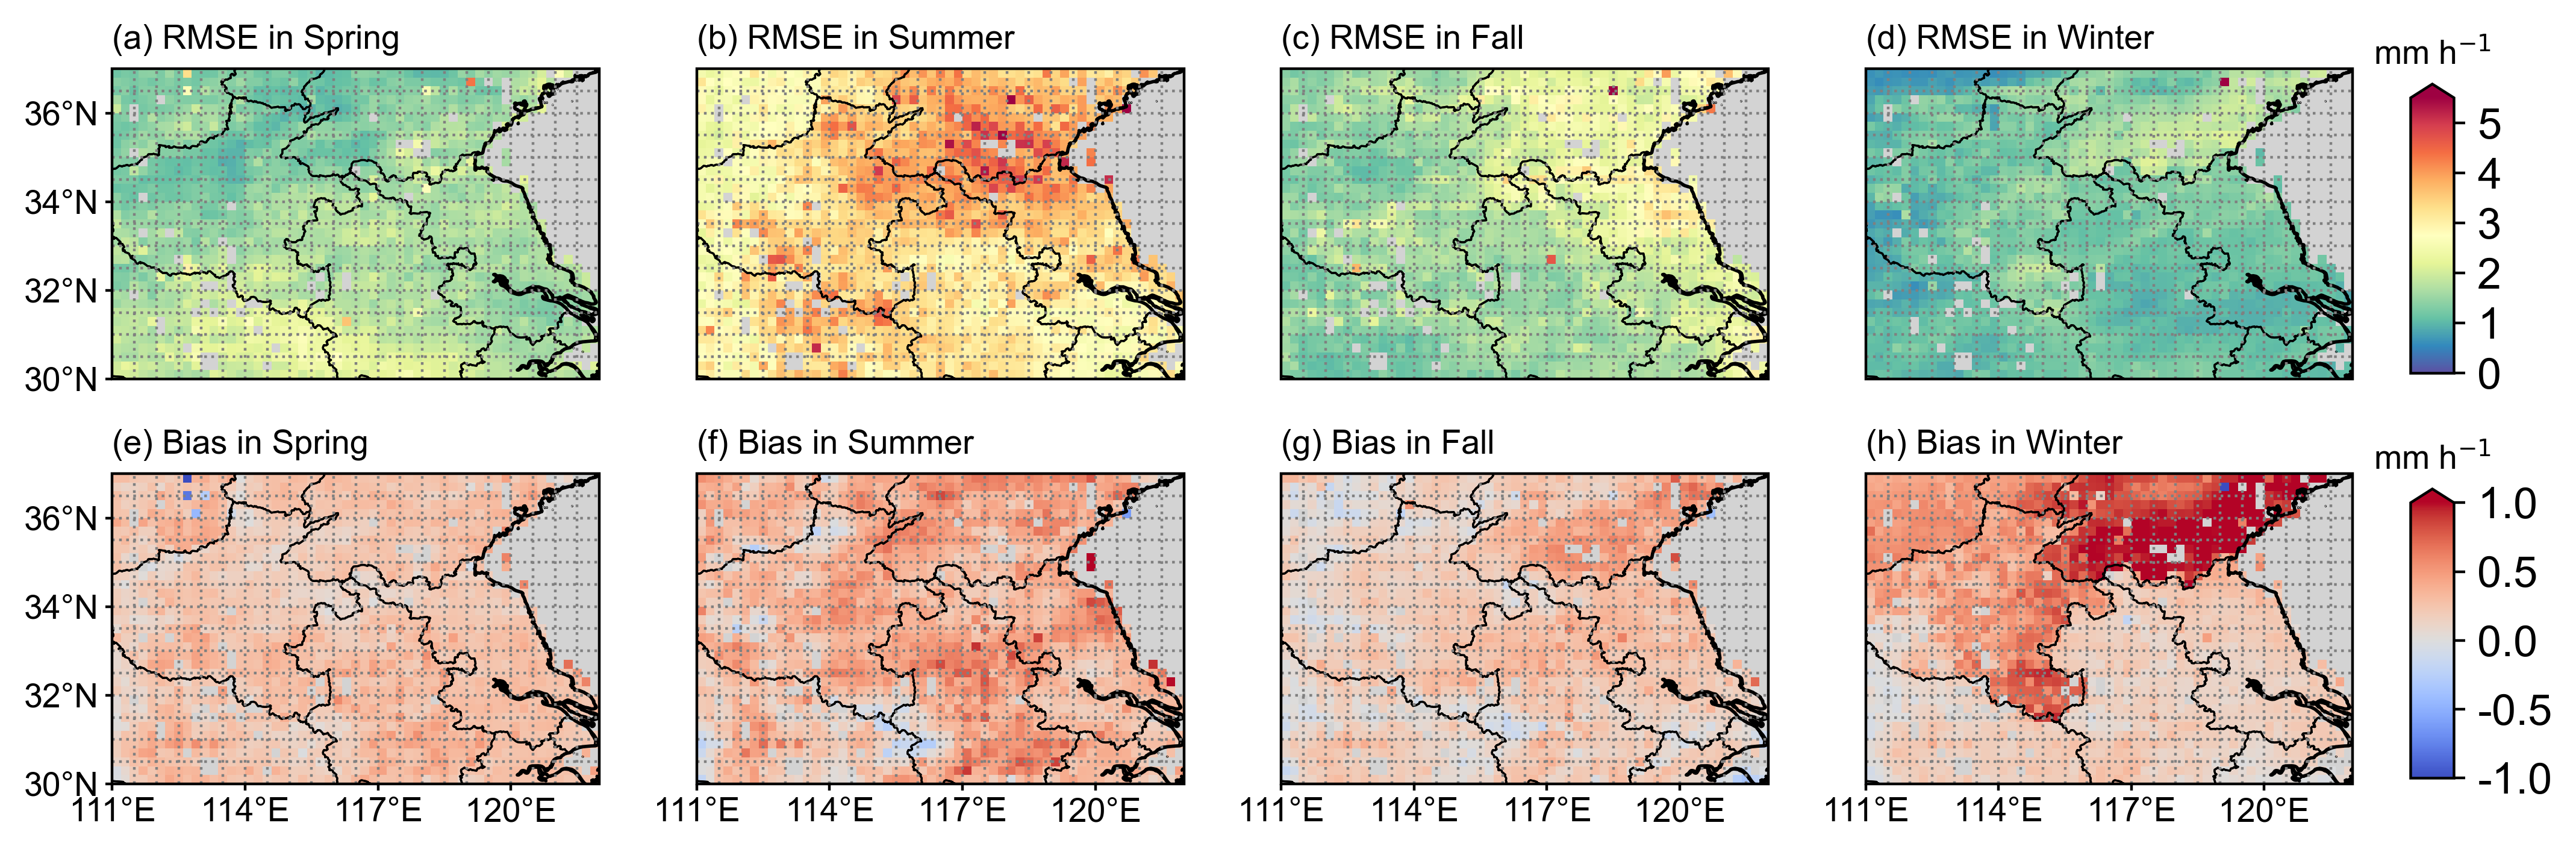

In [18]:

fig, axs = plt.subplots(2, 4, figsize=(12, 4), dpi=400,subplot_kw={'projection': ccrs.PlateCarree()}#,gridspec_kw={'hspace': 0.05 }#'wspace': 0.0,
                        )
axs=axs.ravel()
for i in range(8):
    ax = axs[i]
    ax.coastlines()
    ax.patch.set_facecolor("lightgray") 
    provinces = ShapelyFeature(Reader(shp_path).geometries(), ccrs.PlateCarree(), edgecolor="k", facecolor="none")
    ax.add_feature(provinces, lw=0.6, zorder=2)
    
    ax.set_extent([111, 122, 30, 37], crs=ccrs.PlateCarree())
    
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.8, color="gray", linestyle=":")
    gl.top_labels, gl.bottom_labels, gl.right_labels, gl.left_labels = False, False, False, False
    gl.xlocator = mticker.FixedLocator(np.arange(111, 122, 0.5))
    gl.ylocator = mticker.FixedLocator(np.arange(30, 37, 0.5))
    
    if i==0 or i==4  :
        ax.set_yticks(np.arange(30, 38, 2), crs=ccrs.PlateCarree())
        ax.yaxis.set_major_formatter(LatitudeFormatter())
        ax.tick_params(labelcolor="k", length=2, labelsize=10,rotation=0,pad=2)

    if i in [4,5,6,7]  :
        ax.set_xticks(np.arange(111, 123, 3), crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter())
        ax.tick_params(labelcolor="k", length=2, labelsize=10,rotation=0,pad=2)

    if i in [0,1,2,3]:
        im = ax.imshow(huatus[i],#alpha=colors[i,j],
            cmap=cmap1,
            norm=norm1,
            origin="lower",
            extent=(111, 122, 30, 37),
        )
    if i in [4,5,6,7]:
        im = ax.imshow(huatus[i],#alpha=colors[i,j],
            cmap=cmap2,
            norm=norm2,
            origin="lower",
            extent=(111, 122, 30, 37),
        )
    if i==3:
        cbar_ax = fig.add_axes([0.92, 0.55, 0.015, 0.3])
        cbar=plt.colorbar (im,cax=cbar_ax,extend='max',orientation='vertical',ticks=np.arange(0,5.5,1))
        font = {#'family' : 'serif',
                        #'color'  : 'darkred',
                        #'weight' : 'normal',
                        'size'   : 10,}
        cbar.ax.set_title('mm h$^{-1}$',fontdict=font)
        cbar.ax.tick_params(labelsize=13)
        cbar.minorticks_off()

    if i==7:
        cbar_ax = fig.add_axes([0.92, 0.13, 0.015, 0.3])
        cbar=plt.colorbar (im,cax=cbar_ax,extend='max',orientation='vertical',ticks=np.arange(-2,2.5,0.5))
        font = {#'family' : 'serif',
                        #'color'  : 'darkred',
                        #'weight' : 'normal',
                        'size'   : 10,}
        cbar.ax.set_title('mm h$^{-1}$',fontdict=font)
        cbar.ax.tick_params(labelsize=13)
        cbar.minorticks_off()


#plt.tight_layout()

axs[0].set_title('(a) RMSE in Spring',fontsize=10,loc='left')
axs[1].set_title('(b) RMSE in Summer',fontsize=10,loc='left')
axs[2].set_title('(c) RMSE in Fall',fontsize=10,loc='left')
axs[3].set_title('(d) RMSE in Winter',fontsize=10,loc='left')
axs[4].set_title('(e) Bias in Spring',fontsize=10,loc='left')
axs[5].set_title('(f) Bias in Summer',fontsize=10,loc='left')
axs[6].set_title('(g) Bias in Fall',fontsize=10,loc='left')
axs[7].set_title('(h) Bias in Winter',fontsize=10,loc='left')
# axs[0].annotate('(a)', xy=(0.97, 0.8), xycoords='axes fraction', fontsize=12, ha='right', va='top', bbox=dict(boxstyle="square,pad=0.2", fc="white", ec="none"),alpha=0.8)
# axs[1].annotate('(b)', xy=(0.97, 0.8), xycoords='axes fraction', fontsize=12, ha='right', va='top', bbox=dict(boxstyle="square,pad=0.2", fc="white", ec="none"),alpha=0.8)
# axs[2].annotate('(c)', xy=(0.97, 0.8), xycoords='axes fraction', fontsize=12, ha='right', va='top', bbox=dict(boxstyle="square,pad=0.2", fc="white", ec="none"),alpha=0.8)
# axs[3].annotate('(d)', xy=(0.97, 0.8), xycoords='axes fraction', fontsize=12, ha='right', va='top', bbox=dict(boxstyle="square,pad=0.2", fc="white", ec="none"),alpha=0.8)
# axs[4].annotate('(e)', xy=(0.97, 0.8), xycoords='axes fraction', fontsize=12, ha='right', va='top', bbox=dict(boxstyle="square,pad=0.2", fc="white", ec="none"),alpha=0.8)
# axs[5].annotate('(f)', xy=(0.97, 0.8), xycoords='axes fraction', fontsize=12, ha='right', va='top', bbox=dict(boxstyle="square,pad=0.2", fc="white", ec="none"),alpha=0.8)
# axs[6].annotate('(g)', xy=(0.97, 0.8), xycoords='axes fraction', fontsize=12, ha='right', va='top', bbox=dict(boxstyle="square,pad=0.2", fc="white", ec="none"),alpha=0.8)
# axs[7].annotate('(h)', xy=(0.97, 0.8), xycoords='axes fraction', fontsize=12, ha='right', va='top', bbox=dict(boxstyle="square,pad=0.2", fc="white", ec="none"),alpha=0.8)

# axs[0].set_ylabel('RMSE',fontsize=12)
# axs[4].set_ylabel('Bias',fontsize=12)

plt.show()